(50000, 2)
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Accuracy: 0.8933
              precision    recall  f1-score   support

    negative       0.90      0.89      0.89      5000
    positive       0.89      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



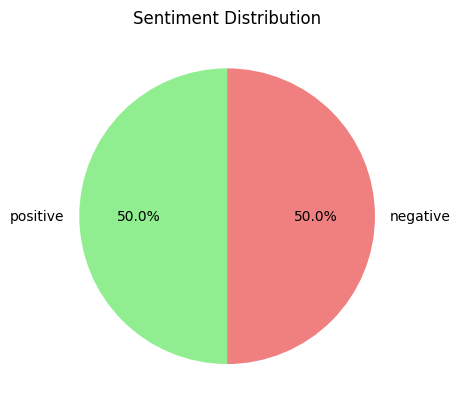

In [8]:
# Sentiment Analysis using TF-IDF and Logistic Regression
import pandas as pd
import numpy as np
import re
import nltk
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from nltk.corpus import stopwords
# df = pd.read_csv("IMDB Dataset.csv")
df = pd.read_csv(
    "IMDB Dataset.csv",
    encoding="utf-8",
    engine="python",
    on_bad_lines="skip"
)

df.head()
print(df.shape)
print(df['sentiment'].value_counts())
# Text Preprocessing
nltk.download('stopwords')
# Cleaning function:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df['clean_review'] = df['review'].apply(clean_text)
# Features and Labels
X = df['clean_review']
y = df['sentiment']
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
# Logistic Regression Model
model = LogisticRegression(max_iter=1000)


model.fit(X_train_tfidf, y_train)
# Predictions
y_pred = model.predict(X_test_tfidf)
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
# Classification Report
print(classification_report(y_test, y_pred))

# Sentiment Distribution Visualization
import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    colors=['lightgreen', 'lightcoral']
)

plt.title("Sentiment Distribution")
plt.ylabel("")
plt.show()


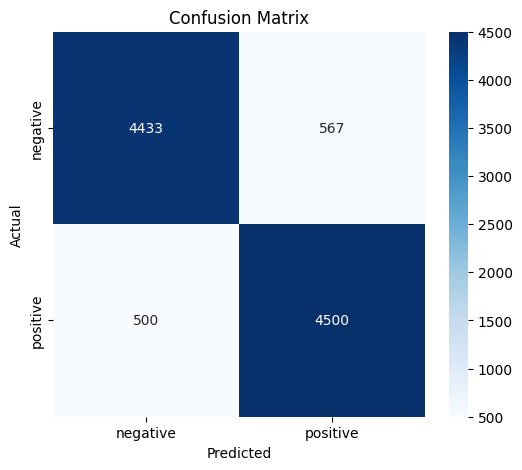

In [9]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)


plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


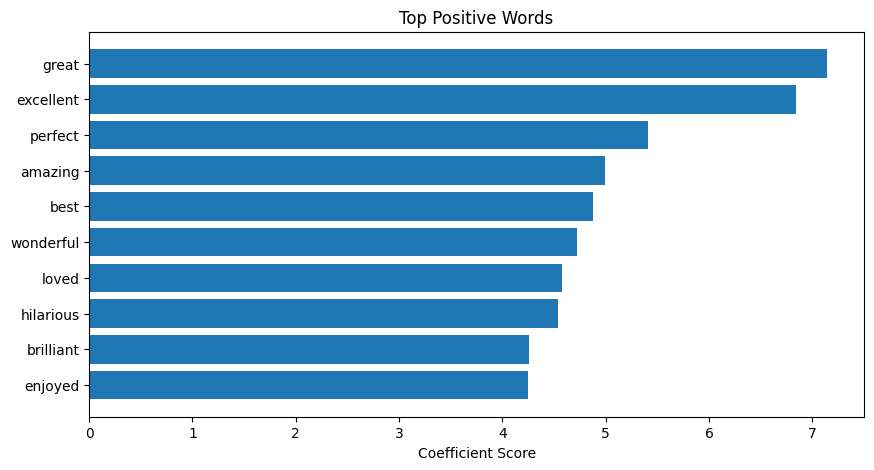

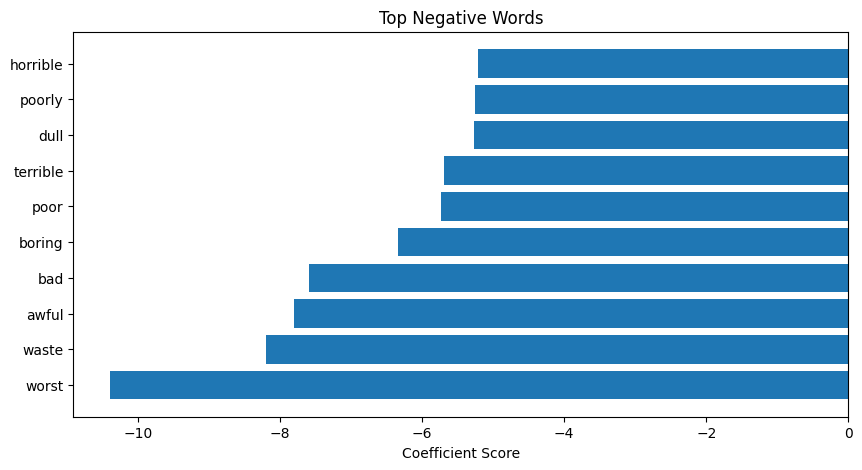

In [10]:
# Most Important Words Visualization
feature_names = tfidf.get_feature_names_out()

coefficients = model.coef_[0]

top_positive = coefficients.argsort()[-10:]
top_negative = coefficients.argsort()[:10]

positive_words = [feature_names[i] for i in top_positive]
negative_words = [feature_names[i] for i in top_negative]

positive_scores = coefficients[top_positive]
negative_scores = coefficients[top_negative]


plt.figure(figsize=(10,5))

plt.barh(positive_words, positive_scores)

plt.title("Top Positive Words")
plt.xlabel("Coefficient Score")

plt.show()

plt.figure(figsize=(10,5))

plt.barh(negative_words, negative_scores)

plt.title("Top Negative Words")
plt.xlabel("Coefficient Score")

plt.show()


In [11]:
# prediction demo
sample_review = ["The movie was amazing and emotionally powerful"]
sample_clean = [clean_text(sample_review[0])]
sample_tfidf = tfidf.transform(sample_clean)

print("Predicted Sentiment:", model.predict(sample_tfidf)[0])


Predicted Sentiment: positive


## Analysis

- TF-IDF vectorization converted text into numerical features.
- Logistic Regression performed well for binary sentiment classification.
- Preprocessing improved text quality by removing stopwords and symbols.
- The confusion matrix shows strong prediction performance.
- The model successfully classified positive and negative reviews.

## Conclusion

A sentiment analysis model was successfully built using TF-IDF Vectorization and Logistic Regression.
The model achieved high accuracy in classifying customer reviews as positive or negative.
This project demonstrates a basic NLP pipeline for sentiment classification.